# TickeTag backend evaluation: zero-shot vs RAG

> **Status:** RAG is the main backend (85.5% accuracy / 0.844 macro F1 on the run
> below, 0 failures). Zero-shot is parked as a future experiment after failing to
> complete a 200-ticket run on two different providers (OpenRouter's daily quota,
> then Gemini's `503 high demand`) — see `Escolhas_projeto.md`. This notebook still
> re-runs cleanly for either backend whenever you want to revisit that comparison.

Compares the two "backend" classification methods in this project —
`ticketag.zeroshot` (LLM zero-shot) and `ticketag.rag` (k-NN vote over a Chroma
knowledge base) — on the **same held-out set of 200 tickets**, so the accuracy
numbers are directly comparable.

## Why the same 200 tickets matter

`ticketag-rag-ingest` streams the whole labeled CSV
(`all_tickets_processed_improved_v3.csv`) into the `tickets` Chroma
collection. If the RAG backend is evaluated on tickets that are *already
inside* its own knowledge base, a query can retrieve the ticket itself (or a
near-duplicate) as its own nearest neighbor and accuracy gets inflated —
classic train/test leakage. This notebook reuses `scripts/holdout_test_sample.py`'s
`select_stratified_holdout_rows` as the single source of truth for the holdout
set: it draws 200 tickets at random, but with per-category counts
**proportional to that category's share of the full 47,837-row CSV** (a plain
tail slice turned out *not* to be representative here — see the note below),
seeded for reproducibility. That gives:

- the **zero-shot run** below classifying exactly these 200 tickets,
- the **RAG run** below classifying the same 200 tickets, after purging their
  ids from the `tickets` collection (Step 2),
- ids lining up 1:1 across both runs and with whatever Chroma already stored
  for them, because both this notebook and `ticketag-rag-ingest` derive the
  ticket id the same way (the CSV row index, as a string) — regardless of
  where in the file a sampled row actually came from, since
  `purge_ids_from_collection` deletes by id, not by position.

**Why not just take the last 200 rows?** This CSV isn't randomly ordered —
`Access` tickets are ~15% of the file overall but nearly disappear in the last
few thousand rows, while `Hardware` ramps up to dominate the tail. A plain
tail slice of 200 rows ended up with `Access` at 2% and `Internal Project` at
a single ticket, which would make most per-category metrics below noise
rather than signal. Proportional stratified sampling fixes that while keeping
everything else (purge-by-id, reproducibility via a fixed seed) intact.

## Metrics used, and why

| Metric | Why |
|---|---|
| **Accuracy** | Headline number, easy to compare at a glance. |
| **Per-category precision / recall / F1** | The taxonomy is imbalanced (see Step 1) — accuracy alone hides a backend that just always guesses the majority class. |
| **Macro F1** | Unweighted average across categories — punishes ignoring rare categories, unlike accuracy or weighted F1. |
| **Weighted F1** | Support-weighted average — the "accuracy-flavored" aggregate that still reflects per-class quality. |
| **Confusion matrix** | Shows *which* categories get confused with which — useful for tuning `TICKETAG_RAG_K` / `TICKETAG_RAG_AUTO_ADD_THRESHOLD` or the zero-shot category descriptions. |
| **Failure / abstention rate** | Share of tickets a backend could not classify at all (model reply didn't parse, knowledge base empty, etc.) — both backend READMEs flag this as a live risk. |
| **Confidence calibration** | Bins predictions by self-reported/vote-share confidence and checks whether higher confidence actually means higher accuracy — both READMEs explicitly call their confidence "uncalibrated". |
| **Throughput (tickets/sec)** | Ties back to the documented cost/latency tradeoff: per-ticket LLM call vs. a vector query. |
| **Cohen's kappa + McNemar's exact test** | Once both backends have run: how often they agree beyond chance, and whether an accuracy gap between them is statistically meaningful on only 200 samples (rather than noise). |

## How to use this notebook

1. Run the **Setup** and **Step 1** cells now — they only read the CSV, no network calls.
2. Run **Step 2** (purge) once `ticketag-rag-ingest` has finished, so the RAG
   evaluation isn't contaminated by its own test set. Safe to re-run — Chroma's
   delete is a no-op for ids that aren't present.
3. Run **Step 3** (zero-shot) any time — it never touches Chroma.
4. Run **Step 4** (RAG) once Step 2 has been done.
5. Run **Step 5** (comparison) once both prediction CSVs exist.

Each backend's predictions are cached to a CSV after the first run, so
re-opening this notebook later reloads them instead of re-spending API calls
or Chroma queries — flip the matching `FORCE_RERUN_*` flag to redo a run.

**Kernel:** select this project's `.venv` interpreter (`uv sync --group
notebook` installs `pandas`/`matplotlib`/`ipykernel` into it).

## Setup

In [4]:
from __future__ import annotations

import csv
import sys
import time
from math import comb
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_project_root(start: Path) -> Path:
    """Walk up from `start` until a directory containing `pyproject.toml` is found."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate the TickeTag project root from {start}")


# Resolved by walking up from the current directory rather than assumed, so this notebook
# works whether Jupyter's cwd is the project root or this notebooks/ folder.
PROJECT_ROOT = find_project_root(Path.cwd())
SCRIPTS_DIR = str(PROJECT_ROOT / "scripts")
if SCRIPTS_DIR not in sys.path:
    sys.path.insert(0, SCRIPTS_DIR)  # holdout_test_sample.py lives here; it isn't a package

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/biabc/Documents/TickeTag


In [ ]:
import os

from ticketag.envfile import load_env_file

# Both backends' Settings.from_env() default to a *relative* ".env", which only resolves
# correctly when the kernel's cwd is the project root. Passing this explicit path (below,
# via env_file=ENV_PATH) keeps every Settings.from_env()/classifier_from_env() call in this
# notebook correct regardless of where Jupyter actually launched the kernel from.
ENV_PATH = PROJECT_ROOT / ".env"
load_env_file(ENV_PATH)

for var in ("GEMINI_API_KEY", "CHROMA_API_KEY"):
    print(f"{var}: {'set' if os.getenv(var) else 'MISSING'}")

In [6]:
# --- Dataset ---
FULL_CSV = PROJECT_ROOT / "all_tickets_processed_improved_v3.csv"
TEXT_COLUMN = "Document"
CATEGORY_COLUMN = "Topic_group"
SAMPLE_SIZE = 200

# --- Holdout sample (shared by both backends) ---
HOLDOUT_CSV = PROJECT_ROOT / "test_sample_200.csv"
# Fixed so a from-scratch rebuild always reproduces the exact same 200 tickets.
HOLDOUT_SEED = 42
# HOLDOUT_CSV already exists on disk (built earlier, and its ids already purged from
# Chroma in Step 2) -> Step 1 below loads it as-is. Only flip this if you want a fresh
# stratified draw, which would also need a fresh Step 2 purge to stay leakage-free.
FORCE_REBUILD_HOLDOUT = False

# --- RAG backend ---
# The project's only Chroma collection. Matches Settings.collection_name default.
RAG_COLLECTION = "tickets"
RAG_WORKERS = 4
RAG_PRED_CSV = PROJECT_ROOT / "predictions_rag_200.csv"
FORCE_RERUN_RAG = False
# Evaluating shouldn't also mutate the collection under test: RAGTicketClassifier writes
# high-confidence predictions back into the knowledge base by default (auto_add_threshold),
# which would seed it with this eval run's own (possibly wrong) predictions for the exact
# tickets being scored. Setting this above 1.0 disables write-back for this run only.
RAG_EVAL_AUTO_ADD_THRESHOLD = 1.01

# --- Zero-shot backend ---
ZEROSHOT_WORKERS = 4
ZEROSHOT_PRED_CSV = PROJECT_ROOT / "predictions_zeroshot_200.csv"
FORCE_RERUN_ZEROSHOT = False

## Step 1 — Load the holdout sample (safe, no network calls)

If `test_sample_200.csv` already exists (it does — it was built earlier and its
ids have already been purged from Chroma in Step 2), this cell **loads it
as-is** rather than drawing a fresh sample, so the tickets scored below are
guaranteed to be the exact same ones already removed from the knowledge base.

Otherwise (first run, or `FORCE_REBUILD_HOLDOUT = True`), it falls back to
`select_stratified_holdout_rows` from `scripts/holdout_test_sample.py`: it
samples `SAMPLE_SIZE` tickets with per-category counts proportional to that
category's share of the full CSV (largest-remainder rounding, seeded with
`HOLDOUT_SEED` for reproducibility), rather than just taking the tail. Ids are
still the 0-based CSV row index — the same convention `ticketag-rag-ingest`
uses — so a fresh Step 2 purge would still target exactly the right ids in
Chroma. If you ever rebuild the holdout from scratch, re-run Step 2 too, since
a new sample means a new set of ids to purge.

This cell only reads a local CSV — it never touches Chroma or an LLM.

Held out 200 ticket(s) (stratified, seed=42)
Wrote test_sample_200.csv


,full_%,holdout_n,holdout_%
Hardware,28.5,57,28.5
HR Support,22.8,46,23.0
Access,14.9,30,15.0
Miscellaneous,14.8,29,14.5
Storage,5.8,12,6.0
Purchase,5.2,10,5.0
Internal Project,4.4,9,4.5
Administrative rights,3.7,7,3.5


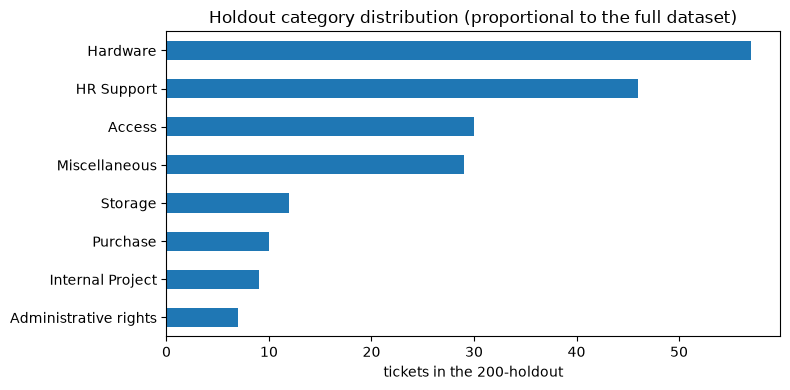

In [ ]:
from holdout_test_sample import select_stratified_holdout_rows, write_holdout_csv

if HOLDOUT_CSV.exists() and not FORCE_REBUILD_HOLDOUT:
    with HOLDOUT_CSV.open(newline="", encoding="utf-8") as handle:
        holdout_rows = [
            (row["ticket_id"], row[TEXT_COLUMN], row[CATEGORY_COLUMN])
            for row in csv.DictReader(handle)
        ]
    print(f"Loaded existing {HOLDOUT_CSV.name} ({len(holdout_rows)} rows) — not regenerating.")
else:
    holdout_rows = select_stratified_holdout_rows(
        FULL_CSV, TEXT_COLUMN, CATEGORY_COLUMN, SAMPLE_SIZE, HOLDOUT_SEED
    )
    write_holdout_csv(holdout_rows, HOLDOUT_CSV, TEXT_COLUMN, CATEGORY_COLUMN)
    print(f"Held out {len(holdout_rows)} ticket(s) (stratified, seed={HOLDOUT_SEED})")
    print(f"Wrote {HOLDOUT_CSV.name}")

gold_by_id = {ticket_id: category for ticket_id, _, category in holdout_rows}

# Compare against the full CSV's category mix to confirm the sample is actually
# proportional, not just "every category appears at least once".
full_counts = pd.read_csv(FULL_CSV, usecols=[CATEGORY_COLUMN])[CATEGORY_COLUMN].value_counts()
holdout_counts = pd.Series(gold_by_id.values()).value_counts()
mix = pd.DataFrame(
    {
        "full_%": (full_counts / full_counts.sum() * 100).round(1),
        "holdout_n": holdout_counts,
        "holdout_%": (holdout_counts / holdout_counts.sum() * 100).round(1),
    }
).sort_values("full_%", ascending=False)
display(mix)

fig, ax = plt.subplots(figsize=(8, 4))
holdout_counts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("tickets in the 200-holdout")
ax.set_title("Holdout category distribution (proportional to the full dataset)")
fig.tight_layout()
plt.show()

rare = holdout_counts[holdout_counts <= 3]
if not rare.empty:
    print(
        "Heads up: these categories still have 3 or fewer examples in the holdout even "
        f"proportionally (they're rare in the full dataset too), so their precision/recall/F1 "
        f"below will be noisy:\n{rare.to_dict()}"
    )

## Step 2 — Purge the holdout ids from the `tickets` collection

**Already done** — this was run earlier and removed all 200 holdout ids from
the `tickets` collection (confirmed: collection count dropped from 47,838 to
47,638). `CONFIRM_PURGE` defaults to `False` below so this cell is a no-op by
default; there's no need to run it again unless Step 1 draws a *new* sample
(different ids), in which case flip it back to `True` once and re-run.

Background, for reference: `ticketag-rag-ingest` was run without `--limit`, so
it ingested **all** rows, including the 200 held out. If they'd stayed in the
collection, the RAG classifier's own nearest-neighbor query for one of these
tickets could retrieve itself (or a near-duplicate) — inflating accuracy. This
cell calls `purge_ids_from_collection` (the same helper
`scripts/holdout_test_sample.py --purge-collection` uses) to fix that. It's
safe to re-run — Chroma's delete is a no-op for ids that aren't present.

In [ ]:
from ticketag.rag import Settings as RagSettings

CONFIRM_PURGE = False  # already done for the current holdout; see Step 2 markdown above

if not CONFIRM_PURGE:
    print("Skipped (already done for the current holdout). Flip CONFIRM_PURGE = True only if")
    print("Step 1 drew a *new* sample and these ids haven't been purged yet.")
else:
    from holdout_test_sample import purge_ids_from_collection

    purge_settings = RagSettings.from_env(env_file=ENV_PATH, collection_name=RAG_COLLECTION)
    holdout_ids = [ticket_id for ticket_id, _, _ in holdout_rows]
    removed = purge_ids_from_collection(holdout_ids, RAG_COLLECTION, purge_settings)
    print(f"Removed {removed} holdout ticket(s) from collection {RAG_COLLECTION!r}.")

Removed 200 holdout ticket(s) from collection 'tickets'.


## Shared classification runner

Used by both Step 3 (zero-shot) and Step 4 (RAG) so the two backends are
driven identically: same `TicketClassificationPipeline`, same holdout order,
same success/failure bookkeeping.

In [11]:
from ticketag.exceptions import TickeTagError
from ticketag.models import ClassifiedTicket, FailedTicket
from ticketag.pipeline import TicketClassificationPipeline

try:
    from tqdm.auto import tqdm

    def make_progress(total: int, desc: str):
        """Return a live tqdm progress bar."""
        return tqdm(total=total, desc=desc)
except ImportError:

    class _NoProgress:
        """No-op stand-in for tqdm when it isn't installed."""

        def update(self, n: int = 1) -> None:
            """Ignore progress updates."""

        def close(self) -> None:
            """Nothing to close."""

    def make_progress(total: int, desc: str):
        """Print a one-line notice instead of a live progress bar."""
        print(f"{desc}: 0/{total} (install tqdm for a live progress bar)")
        return _NoProgress()


def run_backend(
    pipeline: TicketClassificationPipeline, workers: int, desc: str
) -> tuple[pd.DataFrame, float]:
    """Classify every holdout ticket, returning (predictions_df, elapsed_seconds)."""
    tickets = [(ticket_id, text) for ticket_id, text, _ in holdout_rows]
    progress = make_progress(len(tickets), desc)
    records: list[dict[str, object]] = []
    started = time.perf_counter()
    for result in pipeline.run_batch(tickets, max_workers=workers):
        if isinstance(result, ClassifiedTicket):
            records.append(
                {
                    "ticket_id": result.ticket_id,
                    "gold": gold_by_id[result.ticket_id],
                    "predicted": result.classification.category,
                    "confidence": result.classification.confidence,
                    "justification": result.classification.justification,
                    "error": None,
                }
            )
        elif isinstance(result, FailedTicket):
            records.append(
                {
                    "ticket_id": result.ticket_id,
                    "gold": gold_by_id[result.ticket_id],
                    "predicted": None,
                    "confidence": None,
                    "justification": None,
                    "error": result.error,
                }
            )
        progress.update(1)
    progress.close()
    elapsed = time.perf_counter() - started
    return pd.DataFrame.from_records(records), elapsed

## Step 3 — Zero-shot run (runs now, independent of Chroma/ingestion)

Classifies the 200 holdout tickets with `ticketag.zeroshot`. This backend
never touches Chroma, so it can run at any point — including right now, while
`ticketag-rag-ingest` is still loading the knowledge base.

Predictions are cached to `predictions_zeroshot_200.csv`; re-running this cell
later just reloads them unless `FORCE_RERUN_ZEROSHOT = True`.

**Note:** this calls the Gemini Developer API (`GEMINI_API_KEY`, via
`google-genai`). The free tier is rate-limited per project (requests/minute
*and* requests/day); if every ticket fails with a `429`, either wait for the
quota to reset or lower `TICKETAG_REQUESTS_PER_MINUTE` / point `.env`'s
`TICKETAG_MODEL` at a different Gemini model.

In [ ]:
from ticketag.zeroshot import classifier_from_env as zeroshot_classifier_from_env

zeroshot_df: pd.DataFrame | None

if ZEROSHOT_PRED_CSV.exists() and not FORCE_RERUN_ZEROSHOT:
    zeroshot_df = pd.read_csv(ZEROSHOT_PRED_CSV, dtype={"ticket_id": str})
    print(f"Loaded cached {ZEROSHOT_PRED_CSV.name} ({len(zeroshot_df)} rows).")
else:
    try:
        zeroshot_classifier = zeroshot_classifier_from_env(env_file=ENV_PATH)
        zeroshot_pipeline = TicketClassificationPipeline(zeroshot_classifier)
        zeroshot_df, elapsed = run_backend(zeroshot_pipeline, ZEROSHOT_WORKERS, "zero-shot")
        zeroshot_df.to_csv(ZEROSHOT_PRED_CSV, index=False)
        n = len(zeroshot_df)
        print(
            f"Classified {n} tickets in {elapsed:.1f}s ({n / elapsed:.2f} tickets/s) "
            f"-> {ZEROSHOT_PRED_CSV.name}"
        )
    except TickeTagError as error:
        zeroshot_df = None
        print(f"Zero-shot run failed before completing: {error}")

## Metrics helpers

Shared functions used to score both backends identically, so Step 5's
comparison is apples-to-apples. Precision/recall/F1 follow the same
`Counter`-based approach as `scripts/evaluate.py`, extended here with
macro/weighted averages, a confusion matrix, confidence-calibration bins,
Cohen's kappa and an exact McNemar test — all from the standard library plus
`pandas`, no extra statistics dependency needed for these particular metrics.

In [ ]:
from collections import Counter


def classification_report_df(df: pd.DataFrame) -> pd.DataFrame:
    """Per-category precision/recall/F1/support, plus macro-avg/weighted-avg rows.

    `support` (the number of gold examples per category) is counted over every
    row, including ones the backend failed to classify, matching the usual
    definition: how many true instances of the class existed in the eval set.
    """
    scored = df.dropna(subset=["predicted"])
    labels = sorted(set(df["gold"]) | set(scored["predicted"]))
    true_positive, false_positive, false_negative, support = (Counter() for _ in range(4))
    for gold, predicted in zip(scored["gold"], scored["predicted"], strict=True):
        if gold == predicted:
            true_positive[gold] += 1
        else:
            false_positive[predicted] += 1
            false_negative[gold] += 1
    for gold in df["gold"]:
        support[gold] += 1

    rows = []
    for label in labels:
        precision = _safe_div(true_positive[label], true_positive[label] + false_positive[label])
        recall = _safe_div(true_positive[label], true_positive[label] + false_negative[label])
        f1 = _safe_div(2 * precision * recall, precision + recall)
        rows.append(
            {
                "category": label,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "support": support[label],
            }
        )
    report = pd.DataFrame(rows).set_index("category")
    total_support = report["support"].sum()
    report.loc["macro avg"] = {
        "precision": report["precision"].mean(),
        "recall": report["recall"].mean(),
        "f1": report["f1"].mean(),
        "support": total_support,
    }
    report.loc["weighted avg"] = {
        "precision": _weighted_mean(report.loc[labels, "precision"], report.loc[labels, "support"]),
        "recall": _weighted_mean(report.loc[labels, "recall"], report.loc[labels, "support"]),
        "f1": _weighted_mean(report.loc[labels, "f1"], report.loc[labels, "support"]),
        "support": total_support,
    }
    return report


def _safe_div(numerator: float, denominator: float) -> float:
    """Divide, returning 0.0 for the common "no positives at all" edge case."""
    return numerator / denominator if denominator else 0.0


def _weighted_mean(values: pd.Series, weights: pd.Series) -> float:
    """Support-weighted average, 0.0 when there is no support at all."""
    total_weight = weights.sum()
    return float((values * weights).sum() / total_weight) if total_weight else 0.0


def summarize(df: pd.DataFrame, name: str) -> dict[str, object]:
    """Roll a predictions dataframe up into the headline numbers plus the full report."""
    scored = df.dropna(subset=["predicted"])
    accuracy = (scored["gold"] == scored["predicted"]).mean() if len(scored) else float("nan")
    report = classification_report_df(df)
    return {
        "name": name,
        "n_total": len(df),
        "n_scored": len(scored),
        "failure_rate": 1 - len(scored) / len(df) if len(df) else float("nan"),
        "accuracy": accuracy,
        "macro_f1": report.loc["macro avg", "f1"],
        "weighted_f1": report.loc["weighted avg", "f1"],
        "report": report,
    }


def display_report(report: pd.DataFrame) -> pd.DataFrame:
    """Round a classification report for display, keeping `support` a whole number."""
    rounded = report.round(3)
    rounded["support"] = report["support"].astype(int)
    return rounded


def confusion_matrix_df(df: pd.DataFrame) -> pd.DataFrame:
    """Gold (rows) x predicted (columns) counts, over the tickets that got a prediction."""
    scored = df.dropna(subset=["predicted"])
    labels = sorted(set(df["gold"]) | set(scored["predicted"]))
    matrix = pd.DataFrame(0, index=labels, columns=labels)
    for gold, predicted in zip(scored["gold"], scored["predicted"], strict=True):
        matrix.loc[gold, predicted] += 1
    return matrix


def plot_confusion_matrix(matrix: pd.DataFrame, title: str) -> plt.Figure:
    """Render a confusion matrix as an annotated heatmap."""
    fig, ax = plt.subplots(figsize=(7, 6))
    values = matrix.to_numpy()
    image = ax.imshow(values, cmap="Blues")
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual (gold)")
    ax.set_title(title)
    threshold = values.max() / 2 if values.size else 0
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            if values[i, j]:
                ax.text(
                    j, i, int(values[i, j]), ha="center", va="center",
                    color="white" if values[i, j] > threshold else "black",
                )
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig


def confidence_calibration(
    df: pd.DataFrame, bins=(0.0, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01)
) -> pd.DataFrame:
    """Bin predictions by confidence and report observed accuracy per bin.

    A well-calibrated backend's `accuracy` column should climb roughly in step
    with the bucket's confidence range; both backend READMEs currently flag
    their confidence score as unvalidated, so this is the first real check.
    """
    scored = df.dropna(subset=["predicted", "confidence"]).copy()
    scored["correct"] = scored["gold"] == scored["predicted"]
    scored["bucket"] = pd.cut(scored["confidence"], bins=bins, right=False)
    return (
        scored.groupby("bucket", observed=True)["correct"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "accuracy", "count": "n"})
    )


def cohens_kappa(predictions_a: pd.Series, predictions_b: pd.Series) -> float:
    """Agreement between two prediction series beyond what chance alone would give."""
    labels = sorted(set(predictions_a) | set(predictions_b))
    n = len(predictions_a)
    observed_agreement = (predictions_a.to_numpy() == predictions_b.to_numpy()).mean()
    chance_agreement = sum(
        (sum(predictions_a == label) / n) * (sum(predictions_b == label) / n) for label in labels
    )
    if chance_agreement == 1:
        return 1.0
    return (observed_agreement - chance_agreement) / (1 - chance_agreement)


def mcnemar_exact_test(only_a_correct: int, only_b_correct: int) -> float:
    """Exact two-sided McNemar p-value for whether two paired classifiers differ.

    Only the discordant pairs matter: tickets where exactly one backend got it
    right and the other didn't. Tickets where both agreed (right or wrong)
    carry no information about which backend is better.
    """
    n = only_a_correct + only_b_correct
    if n == 0:
        return 1.0
    k = min(only_a_correct, only_b_correct)
    one_sided_p = sum(comb(n, i) for i in range(k + 1)) / 2**n
    return min(2 * one_sided_p, 1.0)

### Zero-shot results

In [ ]:
if zeroshot_df is not None:
    zeroshot_summary = summarize(zeroshot_df, "zero-shot")
    print(
        f"zero-shot: accuracy={zeroshot_summary['accuracy']:.1%}  "
        f"macro F1={zeroshot_summary['macro_f1']:.3f}  "
        f"weighted F1={zeroshot_summary['weighted_f1']:.3f}  "
        f"failed={zeroshot_summary['failure_rate']:.1%} "
        f"({zeroshot_summary['n_total'] - zeroshot_summary['n_scored']}"
        f"/{zeroshot_summary['n_total']})"
    )
    display(display_report(zeroshot_summary["report"]))
    plot_confusion_matrix(confusion_matrix_df(zeroshot_df), "Zero-shot confusion matrix")
    plt.show()
    display(confidence_calibration(zeroshot_df))
else:
    print("No zero-shot predictions yet — run Step 3 above first.")

## Step 4 — RAG run (needs ingestion finished + Step 2 purge done)

Classifies the **same** 200 holdout tickets with `ticketag.rag` against the
`RAG_COLLECTION` collection. Run this only after:

1. `ticketag-rag-ingest` has finished (its terminal prints
   `Ingested N ticket(s)...` when done), and
2. Step 2's purge has removed these 200 ids from that collection — otherwise
   the accuracy below is optimistic (a ticket can retrieve itself as its own
   nearest neighbor).

If this fails with `knowledge base is empty` or a connection error, ingestion
likely isn't done yet — just re-run this cell later. Predictions are cached to
`predictions_rag_200.csv` once it succeeds.

This run also passes `auto_add_threshold=RAG_EVAL_AUTO_ADD_THRESHOLD` (>1.0),
overriding `.env`'s normal threshold so that classifying the holdout does not
also write these tickets' predictions back into the knowledge base — an
evaluation run shouldn't mutate the thing it's evaluating.

In [ ]:
from ticketag.rag import classifier_from_env as rag_classifier_from_env

rag_df: pd.DataFrame | None

if RAG_PRED_CSV.exists() and not FORCE_RERUN_RAG:
    rag_df = pd.read_csv(RAG_PRED_CSV, dtype={"ticket_id": str})
    print(f"Loaded cached {RAG_PRED_CSV.name} ({len(rag_df)} rows).")
else:
    try:
        rag_classifier = rag_classifier_from_env(
            env_file=ENV_PATH,
            collection_name=RAG_COLLECTION,
            auto_add_threshold=RAG_EVAL_AUTO_ADD_THRESHOLD,
        )
        rag_pipeline = TicketClassificationPipeline(rag_classifier)
        rag_df, elapsed = run_backend(rag_pipeline, RAG_WORKERS, "rag")
        rag_df.to_csv(RAG_PRED_CSV, index=False)
        n = len(rag_df)
        print(
            f"Classified {n} tickets in {elapsed:.1f}s ({n / elapsed:.2f} tickets/s) "
            f"-> {RAG_PRED_CSV.name}"
        )
    except TickeTagError as error:
        rag_df = None
        print(
            "RAG run failed — likely still ingesting, or the holdout hasn't been purged yet.\n"
            f"Error: {error}\nRe-run this cell (and Step 2 above) once ready."
        )

### RAG results

In [ ]:
if rag_df is not None:
    rag_summary = summarize(rag_df, "rag")
    print(
        f"rag: accuracy={rag_summary['accuracy']:.1%}  "
        f"macro F1={rag_summary['macro_f1']:.3f}  "
        f"weighted F1={rag_summary['weighted_f1']:.3f}  "
        f"failed={rag_summary['failure_rate']:.1%} "
        f"({rag_summary['n_total'] - rag_summary['n_scored']}/{rag_summary['n_total']})"
    )
    display(display_report(rag_summary["report"]))
    plot_confusion_matrix(confusion_matrix_df(rag_df), "RAG confusion matrix")
    plt.show()
    display(confidence_calibration(rag_df))
else:
    print("No RAG predictions yet — run Step 4 above first.")

## Step 5 — Head-to-head comparison

Only meaningful once both `predictions_zeroshot_200.csv` and
`predictions_rag_200.csv` exist for the identical 200-ticket holdout.

In [ ]:
if zeroshot_df is not None and rag_df is not None:
    zeroshot_summary = summarize(zeroshot_df, "zero-shot")
    rag_summary = summarize(rag_df, "rag")

    comparison = pd.DataFrame(
        [{k: v for k, v in s.items() if k != "report"} for s in (zeroshot_summary, rag_summary)]
    ).set_index("name")
    display(comparison)

    merged = zeroshot_df.merge(rag_df, on=["ticket_id", "gold"], suffixes=("_zeroshot", "_rag"))
    zeroshot_correct = merged["gold"] == merged["predicted_zeroshot"]
    rag_correct = merged["gold"] == merged["predicted_rag"]
    both_correct = int((zeroshot_correct & rag_correct).sum())
    only_zeroshot_correct = int((zeroshot_correct & ~rag_correct).sum())
    only_rag_correct = int((~zeroshot_correct & rag_correct).sum())
    neither_correct = int((~zeroshot_correct & ~rag_correct).sum())
    p_value = mcnemar_exact_test(only_zeroshot_correct, only_rag_correct)
    kappa = cohens_kappa(
        merged["predicted_zeroshot"].fillna("<failed>"), merged["predicted_rag"].fillna("<failed>")
    )

    print(
        f"Both correct: {both_correct} | only zero-shot correct: {only_zeroshot_correct} | "
        f"only RAG correct: {only_rag_correct} | neither: {neither_correct}"
    )
    print(f"McNemar exact test p-value (is the accuracy gap significant?): {p_value:.4f}")
    print(f"Cohen's kappa (prediction agreement beyond chance): {kappa:.3f}")

    non_average_rows = ["macro avg", "weighted avg"]
    zeroshot_report = zeroshot_summary["report"].drop(index=non_average_rows, errors="ignore")
    rag_report = rag_summary["report"].drop(index=non_average_rows, errors="ignore")
    categories = sorted(set(zeroshot_report.index) | set(rag_report.index))

    fig, ax = plt.subplots(figsize=(9, 5))
    positions = range(len(categories))
    width = 0.35
    ax.bar(
        [i - width / 2 for i in positions],
        [zeroshot_report["f1"].get(c, 0.0) for c in categories],
        width,
        label="Zero-shot",
    )
    ax.bar(
        [i + width / 2 for i in positions],
        [rag_report["f1"].get(c, 0.0) for c in categories],
        width,
        label="RAG",
    )
    ax.set_xticks(list(positions))
    ax.set_xticklabels(categories, rotation=45, ha="right")
    ax.set_ylabel("F1 score")
    ax.set_title("Per-category F1: zero-shot vs RAG")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    candidates = (("zero-shot (Step 3)", zeroshot_df), ("RAG (Step 4)", rag_df))
    missing = [name for name, df in candidates if df is None]
    print("Run " + " and ".join(missing) + " before comparing.")

## Interpreting the results

- If **McNemar's p-value** is above ~0.05, don't read too much into which
  backend "won" on accuracy alone — 200 tickets isn't enough to reliably tell a
  small real gap apart from sampling noise.
- Check the **confusion matrices** for asymmetric mistakes (e.g. RAG collapsing
  rare categories into whichever majority class has the most neighbors) before
  tuning `TICKETAG_RAG_K` / `TICKETAG_RAG_AUTO_ADD_THRESHOLD` or the zero-shot
  category descriptions in `ticketag/taxonomy.py`.
- Check **confidence calibration** before trusting either backend's confidence
  score for a downstream "route low-confidence tickets to a human" policy —
  both READMEs currently flag this as unvalidated.
- Categories with very few holdout examples (see Step 1's distribution) will
  have noisy precision/recall/F1 here regardless of which backend is actually
  better; don't tune thresholds off a single-digit support count — ingest more
  labeled examples of those categories first.